# Aula 03 — Estatística Descritiva Aplicada
**Ciência de Dados · Univassouras · Prof. Mesc. Diego Ramos Inácio**

---

Neste roteiro você vai descrever um conjunto de dados clínicos do começo ao fim:
das medidas de resumo até a correlação entre variáveis.

| # | Etapa |
|---|-------|
| 0 | Ambiente e carga dos dados |
| 1 | Visão geral com `describe()` |
| 2 | Tendência central e dispersão (média, mediana, desvio, CV) |
| 3 | Forma da distribuição — assimetria |
| 4 | Quartis, boxplot e detecção de outliers |
| 5 | Correlação entre variáveis (Pearson e Spearman) |
| 6 | Variáveis categóricas e teste qui-quadrado |
| 7 | Fechamento — o que os dados contam |

> Execute cada célula com `Shift + Enter`. Onde houver `_____`, complete com o código.

## 0 · Ambiente e dados

Se ainda não tiver as bibliotecas, tire o `#` da primeira linha e rode uma vez.

In [1]:
# %pip install pandas numpy matplotlib seaborn scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('Ambiente pronto.')

Ambiente pronto.


### O conjunto de dados — *Heart Disease* (Cleveland / UCI)

303 pacientes, com exames e o diagnóstico final. A base original usa nomes
abreviados de colunas; na célula abaixo já renomeamos para deixar mais legível.
Vamos trabalhar principalmente com estas variáveis:

| Coluna | Descrição | Papel |
|--------|-----------|-------|
| `age` | Idade (anos) | numérica |
| `sex` | Sexo (0 = feminino, 1 = masculino) | categórica |
| `trestbps` | Pressão arterial em repouso (mmHg) | numérica |
| `chol` | Colesterol sérico (mg/dl) | numérica |
| `thalach` | Frequência cardíaca máxima atingida (bpm) | numérica |
| `oldpeak` | Depressão do segmento ST no esforço | numérica |
| `ca` | Nº de vasos principais coloridos no exame (0–3) | numérica |
| `target` | Diagnóstico (0 = sem doença, 1 = com doença) | categórica |

In [2]:
# Carga direta de um repositório público (não precisa baixar nada).
url = ('https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/'
       'master/Notebooks/Data/Heart.csv')
df = pd.read_csv(url, index_col=0)

# Renomeia para os nomes usados na aula e converte o diagnóstico para 0/1.
df = df.rename(columns={
    'Age': 'age', 'Sex': 'sex', 'RestBP': 'trestbps', 'Chol': 'chol',
    'MaxHR': 'thalach', 'Oldpeak': 'oldpeak', 'Ca': 'ca', 'AHD': 'target',
})
df['target'] = (df['target'] == 'Yes').astype(int)

print(df.shape, 'linhas x colunas')
df.head()

(303, 14) linhas x colunas


,age,sex,ChestPain,trestbps,chol,Fbs,RestECG,thalach,ExAng,oldpeak,Slope,ca,Thal,target
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,0
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,1
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,1
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,0
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,0


---
## 1 · Visão geral

Antes de calcular qualquer coisa, olhe o todo: quantas colunas são numéricas,
quantas são categóricas e se há valores faltando.

**Tarefa 1.** Rode `describe()` incluindo as colunas categóricas e conte os nulos.

In [3]:
# Dica: df.isnull().sum()  e  df.describe(include='all')

print('Nulos por coluna:')
print(df.isnull().sum())

df.describe(include='all').round(2)

Nulos por coluna:
age          0
sex          0
ChestPain    0
trestbps     0
chol         0
Fbs          0
RestECG      0
thalach      0
ExAng        0
oldpeak      0
Slope        0
ca           4
Thal         2
target       0
dtype: int64


,age,sex,ChestPain,trestbps,chol,Fbs,RestECG,thalach,ExAng,oldpeak,Slope,ca,Thal,target
count,303.00,303.00,303,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301,303.00
unique,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,asymptomatic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,normal,NaN
freq,NaN,NaN,144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166,NaN
mean,54.44,0.68,NaN,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,NaN,0.46
std,9.04,0.47,NaN,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,NaN,0.50
min,29.00,0.00,NaN,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,NaN,0.00
25%,48.00,0.00,NaN,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,NaN,0.00
50%,56.00,1.00,NaN,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,NaN,0.00
75%,61.00,1.00,NaN,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,NaN,1.00


---
## 2 · Tendência central e dispersão

Para `age`, `trestbps` e `chol`, calcule **média**, **mediana**, **desvio padrão**
e **coeficiente de variação** (CV = desvio ÷ média × 100).

> O CV é adimensional: serve para comparar a dispersão de variáveis com unidades diferentes.

**Tarefa 2.** Complete o laço e observe qual das três variáveis é a mais dispersa.

In [4]:
for col in ['age', 'trestbps', 'chol']:
    media = df[col].mean()
    mediana = df[col].median()
    desvio = df[col].std()
    cv = desvio / media * 100
    print(f'{col:9s} | média={media:7.2f} | mediana={mediana:7.2f} '
          f'| desvio={desvio:6.2f} | CV={cv:5.1f}%')

age       | média=  54.44 | mediana=  56.00 | desvio=  9.04 | CV= 16.6%
trestbps  | média= 131.69 | mediana= 130.00 | desvio= 17.60 | CV= 13.4%
chol      | média= 246.69 | mediana= 241.00 | desvio= 51.78 | CV= 21.0%


---
## 3 · Forma da distribuição

Quando **média e mediana** ficam distantes, a distribuição é assimétrica.
O sinal da assimetria (`skew`) diz para que lado está a cauda:

- `skew > 0` → cauda à direita (média puxada para cima)
- `skew ≈ 0` → aproximadamente simétrica
- `skew < 0` → cauda à esquerda

**Tarefa 3.** Calcule a assimetria de `chol`, compare média e mediana e diga
se a distribuição é simétrica. Confirme com um histograma.

média   = 246.7
mediana = 241.0
skew    = 1.14


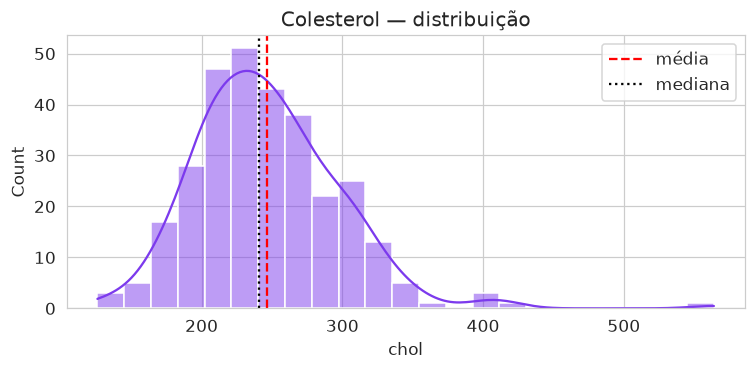

In [5]:
media = df['chol'].mean()
mediana = df['chol'].median()
assimetria = df['chol'].skew()   # método de assimetria

print(f'média   = {media:.1f}')
print(f'mediana = {mediana:.1f}')
print(f'skew    = {assimetria:.2f}')

plt.figure(figsize=(7, 3.5))
sns.histplot(df['chol'], kde=True, color='#7c3aed')
plt.axvline(media, color='red', ls='--', label='média')
plt.axvline(mediana, color='black', ls=':', label='mediana')
plt.title('Colesterol — distribuição')
plt.legend(); plt.tight_layout(); plt.show()

# Responda em uma frase: a distribuição é simétrica? Para que lado está a cauda?

---
## 4 · Quartis, boxplot e outliers

Dois critérios usuais para marcar um ponto como outlier:

- **IQR:** fora de `[Q1 − 1,5·IQR ; Q3 + 1,5·IQR]`, com `IQR = Q3 − Q1`
- **Z-score:** `|z| > 3`, com `z = (x − média) / desvio`

**Tarefa 4.** Calcule os quartis de `chol`, aplique os dois critérios e compare
quantos outliers cada um encontra.

In [6]:
Q1 = df['chol'].quantile(0.25)
Q3 = df['chol'].quantile(0.75)
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

out_iqr = df[(df['chol'] < lim_inf) | (df['chol'] > lim_sup)]

z = (df['chol'] - df['chol'].mean()) / df['chol'].std()
out_z = df[z.abs() > 3]

print(f'Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}  limites=({lim_inf:.0f}; {lim_sup:.0f})')
print(f'Outliers por IQR....: {len(out_iqr)}')
print(f'Outliers por Z-score: {len(out_z)}')

Q1=211  Q3=275  IQR=64  limites=(115; 371)
Outliers por IQR....: 5
Outliers por Z-score: 4


**Tarefa 5.** Faça um boxplot de `thalach` (frequência cardíaca máxima) separado
por `target`. O grupo com doença tende a atingir frequências mais altas ou mais baixas?

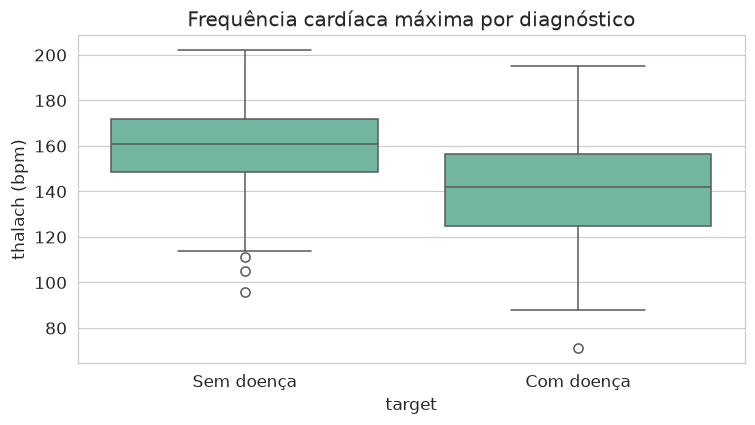

target
0    161.0
1    142.0
Name: thalach, dtype: float64


In [7]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='target', y='thalach')
plt.xticks([0, 1], ['Sem doença', 'Com doença'])
plt.ylabel('thalach (bpm)')
plt.title('Frequência cardíaca máxima por diagnóstico')
plt.tight_layout(); plt.show()

print(df.groupby('target')['thalach'].median())

---
## 5 · Correlação entre variáveis

- **Pearson** mede relação **linear**; sofre com outliers.
- **Spearman** mede relação **monotônica** (ordem); é mais robusto.

**Tarefa 6.** Calcule Pearson e Spearman entre `age` e `thalach`, depois monte
o mapa de calor de correlação (Pearson) de todas as colunas numéricas.

Pearson  r = -0.394  (p = 0.0000)
Spearman ρ = -0.392  (p = 0.0000)


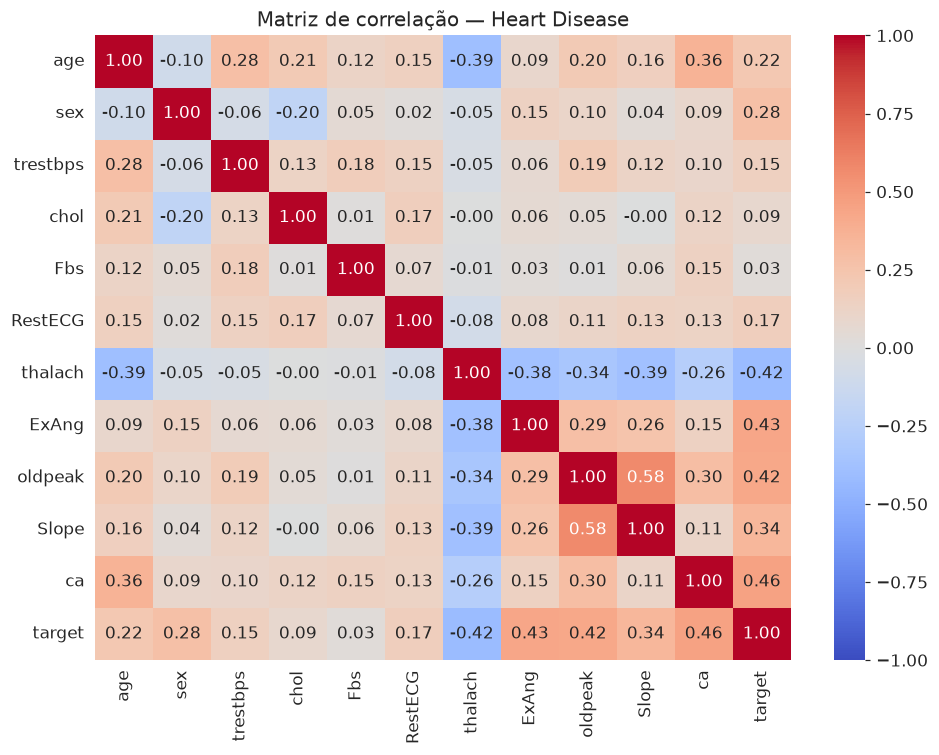

In [8]:
r, p = stats.pearsonr(df['age'], df['thalach'])          # Pearson
rho, p_s = stats.spearmanr(df['age'], df['thalach'])       # Spearman
print(f'Pearson  r = {r:+.3f}  (p = {p:.4f})')
print(f'Spearman ρ = {rho:+.3f}  (p = {p_s:.4f})')

corr = df.corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de correlação — Heart Disease')
plt.tight_layout(); plt.show()

**Tarefa 7 (bônus).** A partir da matriz `corr`, encontre por código o par de
variáveis **diferentes** com maior correlação em módulo.

In [9]:
# Dica: corr.abs(), remova a diagonal, use .unstack().sort_values()

pares = (corr.where(~np.eye(len(corr), dtype=bool))
             .corr().unstack().dropna().sort_values(ascending=False))
print(pares.head(6))

age      age        1.0
sex      sex        1.0
ca       ca         1.0
thalach  thalach    1.0
Fbs      Fbs        1.0
RestECG  RestECG    1.0
dtype: float64


#### Como ler a saída de `pares`

Cada linha é um par de colunas e o **valor absoluto** da correlação entre elas,
da maior para a menor. O par aparece **duas vezes** (`Slope–oldpeak` e
`oldpeak–Slope`) porque a matriz de correlação é simétrica: a relação de A com B
é a mesma de B com A.

**De-para das colunas** (a base original vem em inglês e abreviada):

| Coluna | Significado |
|--------|-------------|
| `age` | Idade, em anos |
| `sex` | Sexo — 0 = feminino, 1 = masculino |
| `ChestPain` | Tipo de dor no peito (típica, atípica, não anginosa, assintomática) |
| `trestbps` | Pressão arterial em repouso (mmHg) |
| `chol` | Colesterol sérico (mg/dl) |
| `Fbs` | Glicemia em jejum > 120 mg/dl — 1 = sim, 0 = não |
| `RestECG` | Resultado do eletrocardiograma em repouso |
| `thalach` | Frequência cardíaca máxima atingida no esforço (bpm) |
| `ExAng` | Angina (dor no peito) provocada pelo exercício — 1 = sim, 0 = não |
| `oldpeak` | Queda do segmento ST no esforço em relação ao repouso (mede isquemia) |
| `Slope` | Inclinação do segmento ST no pico do exercício (subindo, plano, descendo) |
| `ca` | Nº de vasos principais (0 a 3) visíveis na fluoroscopia |
| `Thal` | Resultado do exame de talassemia (normal, defeito fixo, defeito reversível) |
| `target` | Diagnóstico final — 0 = sem doença cardíaca, 1 = com doença |

**Lendo os pares mais fortes:**

| Par | Valor | Leitura |
|-----|-------|---------|
| `Slope` × `oldpeak` | ~0,58 | Medem o mesmo fenômeno — o comportamento do segmento ST durante o esforço — então andam juntas |
| `target` × `ca` | ~0,46 | Quanto mais vasos comprometidos, maior a chance de diagnóstico positivo |
| `target` × `ExAng` | ~0,43 | Ter angina durante o exercício está associado à presença de doença |
| `target` × `oldpeak` | ~0,42 | Maior queda do segmento ST, maior associação com doença |

Todos os valores são positivos e **nenhum passa de 0,6**: num conjunto clínico real,
nenhum exame isolado "fecha" o diagnóstico — ele vem da combinação de vários sinais.

---
## 6 · Variáveis categóricas

Para duas variáveis categóricas usamos a **tabela de contingência** e o **teste
qui-quadrado**: `p < 0,05` indica associação (as variáveis não são independentes).

**Tarefa 8.** Monte a tabela `sex` × `target`, veja as proporções por linha e
aplique o qui-quadrado.

In [13]:
from scipy.stats import chi2_contingency

tab = pd.crosstab(df['sex'], df['target'])
print('Contagem:'); print(tab)
print('\nProporção por linha:')
print(pd.crosstab(df['sex'], df['target'], normalize='index').round(3))

chi2, p, dof, esperado = chi2_contingency(tab)
print(f'\nχ² = {chi2:.2f} | gl = {dof} | p = {p:.4f}')
print('Associação significativa.' if p < 0.05 else 'Sem associação.')

Contagem:
target   0    1
sex            
0       72   25
1       92  114

Proporção por linha:
target      0      1
sex                 
0       0.742  0.258
1       0.447  0.553

χ² = 22.04 | gl = 1 | p = 0.0000
Associação significativa.


---
## 7 · Fechamento

Responda em texto (dois cliques para editar cada célula):

**a)** Para descrever o colesterol dos pacientes num relatório, você usaria a média
ou a mediana? Justifique com o que viu nas Tarefas 3 e 4.

**b)** A correlação entre `age` e `thalach` foi negativa. Isso prova que envelhecer
*causa* redução da frequência cardíaca máxima? Explique.

**c)** O qui-quadrado apontou associação entre `sex` e `target`. Que cuidado é
preciso ter antes de concluir que "homens têm mais doença cardíaca"?

**a)** *A mediana, pois ela é uma medida robusta que não é distorcida por valores discrepantes (outliers) ou pela assimetria na distribuição do colesterol.*

**b)** *Não. Correlação indica apenas associação linear entre as variáveis, e não relação de causalidade.*

**c)** *É preciso analisar as proporções em vez das contagens absolutas.*

---
**Ciência de Dados · Aula 03 · Prof. Mesc. Diego Ramos Inácio · Univassouras · 2026**